<a href="https://colab.research.google.com/github/shadowcompiles/cap-comp215/blob/2026.01/Extended_Forest_Fire_Cellular_Automaton_Kim_Nouriyekdel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extended Forest Fire Cellular Automaton: The Effect of Wind on Fire Spread

**Author:** Kim Nouriyekdel  
**Date:** April 8, 2026  
**Course:** COMP 215  

## Purpose
This project develops an extended two-dimensional cellular automaton model of forest fire dynamics. The model uses NumPy arrays to represent a forest landscape and Matplotlib to visualize how the system changes over time. The extension added in this project is a wind parameter that increases fire spread in one direction. A computational experiment is used to investigate how wind strength affects fire behavior. The project also includes an analysis of algorithm time complexity.


## Project Overview

In this model, each cell in a grid represents a location on a landscape. A cell can be in one of three states:

- empty
- occupied by forest
- burning

At each time step, the model applies these rules:

1. Empty cells may regenerate into forest.
2. Forested cells may ignite spontaneously.
3. Burning cells become empty in the next step.
4. Forested cells may catch fire from burning neighbors.
5. Wind increases the chance of fire spreading in one chosen direction.

This model is an extension of the forest fire cellular automaton explored in the course labs.

## Scientific Question

How does wind strength affect the peak amount of burning and the total amount of fire activity in the model?

## Hypothesis

It is hypothesized that increasing wind strength will increase both the peak proportion of burning cells and the total fire activity, because wind makes directional fire spread more likely.


In [78]:
%matplotlib inline

import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation

matplotlib.rc('animation', html='jshtml')
np.random.seed(42)


In [79]:
def plot_2d_array(array, axes=None, title='', cmap=None, **options):
    """
    Plot a 2D NumPy array as an image.
    """
    axes = axes or plt.gca()
    axes.set_title(title)
    axes.tick_params(
        axis='both', which='both',
        bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False
    )
    options = {**dict(interpolation='nearest', origin='upper'), **options}
    axes.imshow(array, cmap=cmap, **options)


class Animation2D:
    """
    Animate a 2D simulation model that has step() and draw() methods.
    """
    def __init__(self, model, frames=50, steps_per_frame=1, figsize=(6, 6)):
        self.model = model
        self.frames = frames
        self.steps_per_frame = steps_per_frame
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def animation_step(self, step):
        if step > 0:
            for _ in range(self.steps_per_frame):
                self.model.step()
        self.ax.clear()
        self.model.draw(self.ax, step=step * self.steps_per_frame)

    def show(self):
        anim = animation.FuncAnimation(self.fig, self.animation_step, frames=self.frames)
        plt.close()
        return anim


## Model States and Extension

The landscape is stored as a NumPy matrix.

The model uses these integer values:

- `0` = empty
- `1` = forest
- `2` = burning

The main extension in this project is wind. Wind does not create fire by itself, but it increases the probability that fire spreads in one direction. For example, if the wind direction is east, then fire is more likely to spread eastward than in the other directions.


In [80]:
class ExtendedForestFire:
    """
    Extended forest fire cellular automaton with directional wind.
    """

    EMPTY = 0
    FOREST = 1
    FIRE = 2

    colour_map = matplotlib.colors.ListedColormap([
        (0.82, 0.62, 0.42),  # empty = brown
        (0.10, 0.60, 0.20),  # forest = green
        (0.90, 0.15, 0.10)   # fire = red
        ])

    def __init__(self, n, p=0.01, f=0.001, s=0.25, wind_direction='E', wind_strength=0.0, q=0.6):
        """
        Parameters
        ----------
        n : int
            Grid size, creating an n x n landscape.
        p : float
            Probability that an empty cell regenerates into forest.
        f : float
            Probability that a forest cell ignites spontaneously.
        s : float
            Base probability that fire spreads from a burning neighbor.
        wind_direction : str
            One of 'N', 'S', 'E', 'W'.
        wind_strength : float
            Extra spread probability added in the wind direction.
        q : float
            Initial probability that a cell starts as forest.
        """
        self.n = n
        self.p = p
        self.f = f
        self.s = s
        self.wind_direction = wind_direction
        self.wind_strength = wind_strength

        self.state = np.random.choice(
            [self.FOREST, self.EMPTY],
            size=(n, n),
            p=[q, 1 - q])

    def step(self):
        """
        Advance the model by one time step.
        """
        state = self.state

        forest = state == self.FOREST
        empty = state == self.EMPTY
        burning = state == self.FIRE

        next_state = state.copy()

        # Rule 1: burning cells burn out and become empty
        next_state[burning] = self.EMPTY

        # Rule 2: empty cells regenerate into forest
        regenerate = empty & (np.random.random(state.shape) < self.p)
        next_state[regenerate] = self.FOREST

        # Identify burning neighbors in each cardinal direction
        north_burning = np.roll(burning, 1, axis=0)
        south_burning = np.roll(burning, -1, axis=0)
        west_burning = np.roll(burning, 1, axis=1)
        east_burning = np.roll(burning, -1, axis=1)

        spread_prob = {
            'N': self.s,
            'S': self.s,
            'E': self.s,
            'W': self.s}
        spread_prob[self.wind_direction] += self.wind_strength

        ignite_north = forest & north_burning & (np.random.random(state.shape) < spread_prob['N'])
        ignite_south = forest & south_burning & (np.random.random(state.shape) < spread_prob['S'])
        ignite_east = forest & east_burning & (np.random.random(state.shape) < spread_prob['E'])
        ignite_west = forest & west_burning & (np.random.random(state.shape) < spread_prob['W'])

        spread_fire = ignite_north | ignite_south | ignite_east | ignite_west

        # Rule 3: spontaneous ignition
        lightning = forest & (np.random.random(state.shape) < self.f)

        next_state[spread_fire | lightning] = self.FIRE
        self.state = next_state

    def pct_forest(self):
        """
        Return the proportion of forest cells.
        """
        return np.count_nonzero(self.state == self.FOREST) / self.state.size

    def pct_fire(self):
        """
        Return the proportion of burning cells.
        """
        return np.count_nonzero(self.state == self.FIRE) / self.state.size

    def draw(self, axes=None, step=''):
        """
        Draw the landscape.
        """
        axes = axes or plt.gca()
        title = (
            f"Time: {step} | Forest: {self.pct_forest():.2%} | "
            f"Fire: {self.pct_fire():.2%}")
        plot_2d_array(
            self.state,
            axes=axes,
            title=title,
            cmap=self.colour_map,
            vmin=0,
            vmax=2)


## Running the Simulation

The next function runs the model for a chosen number of time steps and records how much of the landscape is forested and how much is burning. These values are later used for plotting and analysis.


In [81]:
def run_simulation(model, steps=1000):
    """
    Run the model and record forest and fire proportions over time.
    """
    forest_history = []
    fire_history = []

    for _ in range(steps):
        model.step()
        forest_history.append(model.pct_forest())
        fire_history.append(model.pct_fire())

    return np.array(forest_history), np.array(fire_history)


In [82]:
model = ExtendedForestFire(
    n=80,
    p=0.01,
    f=0.001,
    s=0.25,
    wind_direction='E',
    wind_strength=0.10,
    q=0.6)

forest_history, fire_history = run_simulation(model, steps=1200)


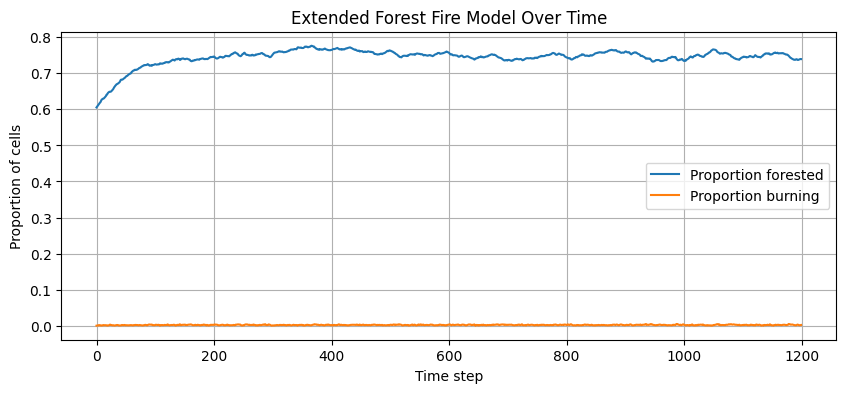

In [83]:
plt.figure(figsize=(10, 4))
plt.plot(forest_history, label='Proportion forested')
plt.plot(fire_history, label='Proportion burning')
plt.xlabel('Time step')
plt.ylabel('Proportion of cells')
plt.title('Extended Forest Fire Model Over Time')
plt.legend()
plt.grid(True)
plt.show()


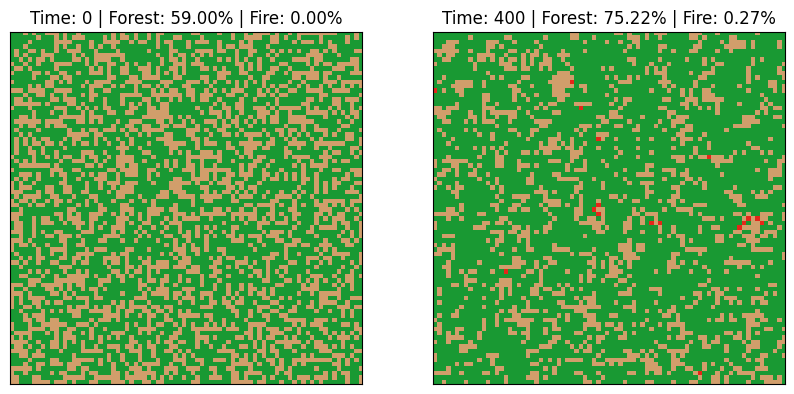

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

model_start = ExtendedForestFire(
    n=80,
    p=0.01,
    f=0.001,
    s=0.25,
    wind_direction='E',
    wind_strength=0.10,
    q=0.6)
model_start.draw(axes[0], step=0)

for _ in range(400):
    model_start.step()

model_start.draw(axes[1], step=400)
plt.show()


## Interpretation of the Initial Simulation

The graph shows that the system changes over time instead of reaching a fixed pattern. Forest cover rises as empty cells regenerate, while fire appears in smaller bursts. This suggests that the model approaches a dynamic steady state, where the landscape keeps changing but remains within a certain range.

The two landscape images also show that the spatial pattern changes over time. Burning cells create gaps in the forest, and the wind parameter can make spread more directional.


## Experimental Parameters

The following parameter values were used for the main experiment:

- grid size: `n = 100`
- regeneration probability: `p = 0.01`
- spontaneous ignition probability: `f = 0.001`
- base spread probability: `s = 0.25`
- initial forest density: `q = 0.6`
- wind direction: east
- wind strengths tested: `0.00, 0.05, 0.10, 0.15, 0.20`
- trials per wind strength: `8`
- time steps per trial: `1500`


## Computational Experiment

To answer the scientific question, the model is run several times with different wind strengths while keeping the other parameters fixed.

The wind strengths tested are:

- 0.00
- 0.05
- 0.10
- 0.15
- 0.20

For each wind strength, the model records:

- the average peak proportion of burning cells
- the average total fire activity

The total fire activity is measured as the sum of burning proportions across all time steps. Multiple trials are used to reduce random variation.


In [85]:
def summarize_trial(n, p, f, s, wind_direction, wind_strength, q, steps):
    """
    Run one trial and return summary measures.
    """
    model = ExtendedForestFire(
        n=n,
        p=p,
        f=f,
        s=s,
        wind_direction=wind_direction,
        wind_strength=wind_strength,
        q=q)

    forest_history, fire_history = run_simulation(model, steps=steps)

    peak_fire = np.max(fire_history)
    total_fire_activity = np.sum(fire_history)
    avg_forest = np.mean(forest_history[-300:])

    return peak_fire, total_fire_activity, avg_forest


def run_experiment(wind_strengths, trials=8, n=100, p=0.01, f=0.001, s=0.25, wind_direction='E', q=0.6, steps=1500):
    """
    Run multiple trials for each wind strength and average the results.
    """
    avg_peak_fire = []
    avg_total_fire = []
    avg_forest_cover = []

    for w in wind_strengths:
        peak_list = []
        total_list = []
        forest_list = []

        for _ in range(trials):
            peak_fire, total_fire_activity, avg_forest = summarize_trial(
                n=n,
                p=p,
                f=f,
                s=s,
                wind_direction=wind_direction,
                wind_strength=w,
                q=q,
                steps=steps)
            peak_list.append(peak_fire)
            total_list.append(total_fire_activity)
            forest_list.append(avg_forest)

        avg_peak_fire.append(np.mean(peak_list))
        avg_total_fire.append(np.mean(total_list))
        avg_forest_cover.append(np.mean(forest_list))

    return np.array(avg_peak_fire), np.array(avg_total_fire), np.array(avg_forest_cover)


In [86]:
wind_strengths = [0.00, 0.05, 0.10, 0.15, 0.20]

avg_peak_fire, avg_total_fire, avg_forest_cover = run_experiment(
    wind_strengths=wind_strengths,
    trials=8,
    n=100,
    p=0.01,
    f=0.001,
    s=0.25,
    wind_direction='E',
    q=0.6,
    steps=1500)

for w, peak, total, forest in zip(wind_strengths, avg_peak_fire, avg_total_fire, avg_forest_cover):
    print(
        f"wind_strength = {w:.2f} | "
        f"avg peak fire = {peak:.4f} | "
        f"avg total fire activity = {total:.4f} | "
        f"avg forest cover = {forest:.4f}")


wind_strength = 0.00 | avg peak fire = 0.0045 | avg total fire activity = 3.2873 | avg forest cover = 0.7745
wind_strength = 0.05 | avg peak fire = 0.0045 | avg total fire activity = 3.4505 | avg forest cover = 0.7628
wind_strength = 0.10 | avg peak fire = 0.0048 | avg total fire activity = 3.6105 | avg forest cover = 0.7520
wind_strength = 0.15 | avg peak fire = 0.0050 | avg total fire activity = 3.7854 | avg forest cover = 0.7416
wind_strength = 0.20 | avg peak fire = 0.0051 | avg total fire activity = 3.9707 | avg forest cover = 0.7293


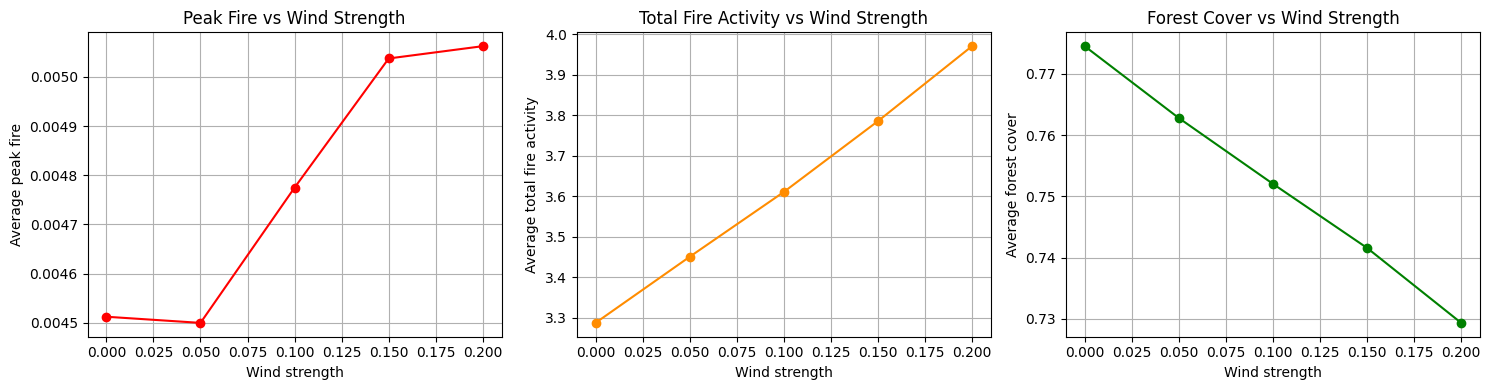

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(wind_strengths, avg_peak_fire, marker='o', color='red')
axes[0].set_xlabel('Wind strength')
axes[0].set_ylabel('Average peak fire')
axes[0].set_title('Peak Fire vs Wind Strength')
axes[0].grid(True)

axes[1].plot(wind_strengths, avg_total_fire, marker='o', color='darkorange')
axes[1].set_xlabel('Wind strength')
axes[1].set_ylabel('Average total fire activity')
axes[1].set_title('Total Fire Activity vs Wind Strength')
axes[1].grid(True)

axes[2].plot(wind_strengths, avg_forest_cover, marker='o', color='green')
axes[2].set_xlabel('Wind strength')
axes[2].set_ylabel('Average forest cover')
axes[2].set_title('Forest Cover vs Wind Strength')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## Experimental Results

The results show how wind strength changes the behavior of the model. In general, stronger wind increases the peak amount of fire and also increases total fire activity. This supports the hypothesis that wind makes fire spread more easily across the landscape.

The results may also show some change in average forest cover. If fire spreads more effectively under stronger wind, then long-term forest cover may decrease because more of the landscape burns before it can recover.

Overall, the experiment suggests that wind is an important factor in this extended model because it changes both the intensity and the total amount of fire.


## Why Multiple Trials Were Used

This model includes randomness because regeneration, spontaneous ignition, and fire spread are all probabilistic. Because of this, a single simulation run may not be fully representative. Running multiple trials and averaging the results makes the experiment more reliable and reduces the influence of chance variation.


In [88]:
anim_model = ExtendedForestFire(
    n=50,
    p=0.01,
    f=0.001,
    s=0.25,
    wind_direction='E',
    wind_strength=0.15,
    q=0.6)

Animation2D(anim_model, frames=80, steps_per_frame=1, figsize=(6, 6)).show()


## Time Complexity Analysis

Let the grid size be `n x n`. This means the landscape contains `n^2` cells.

During each time step, the algorithm checks the whole grid to identify empty, forest, and burning cells. It also performs constant-time directional neighbor checks using NumPy operations. Therefore, the work required for one step is:

`O(n^2)`

If the simulation runs for `t` time steps, then one full simulation requires:

`O(tn^2)`

If the experiment tests `k` different wind strengths and uses `r` trials for each one, then the total time complexity becomes:

`O(krtn^2)`

This means runtime grows:
- linearly with the number of time steps
- linearly with the number of trials
- linearly with the number of tested parameter values
- quadratically with grid size


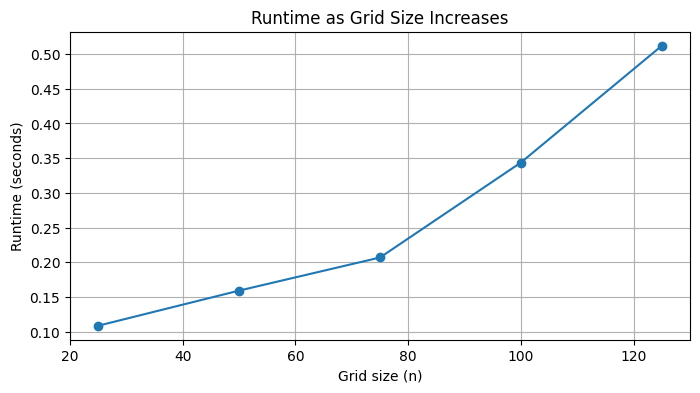

In [89]:
sizes = [25, 50, 75, 100, 125]
times = []

for n in sizes:
    start = time.perf_counter()

    model = ExtendedForestFire(
        n=n,
        p=0.01,
        f=0.001,
        s=0.25,
        wind_direction='E',
        wind_strength=0.10,
        q=0.6)
    run_simulation(model, steps=500)

    end = time.perf_counter()
    times.append(end - start)

plt.figure(figsize=(8, 4))
plt.plot(sizes, times, marker='o')
plt.xlabel('Grid size (n)')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime as Grid Size Increases')
plt.grid(True)
plt.show()


## Runtime Discussion

The runtime graph shows that larger grids take longer to simulate. This is expected because the number of cells grows as `n^2`. The observed increase in runtime is consistent with the theoretical time complexity analysis.

Although the measured times depend on the computer and small random differences, the overall trend supports the conclusion that the simulation cost increases quickly as the landscape becomes larger.


## Limitations

This model is still a simplified representation of a real forest ecosystem.

Some limitations are:

- the landscape only has three states
- all cells use the same probabilities
- wind only affects spread probability in one direction
- weather, slope, and different tree species are not included
- burning lasts only one time step
- the model is an abstraction and not a real fire prediction system

Because of these limits, the model is most useful for exploring general patterns rather than making real-world forecasts.


## Conclusion

In this project, I created an extended forest fire cellular automaton using NumPy and Matplotlib. The model represented a forest landscape on a two-dimensional grid and simulated regeneration, spontaneous ignition, fire spread, and the effect of wind.

The experiment was used to study how wind strength affects fire behavior. The results showed that as wind strength increased from `0.00` to `0.20`, both the average peak fire and the total fire activity increased, while the average forest cover decreased. This supports the hypothesis that stronger wind makes fire spread more easily across the landscape.

Overall, this project met the main goals by using simulation modelling, computational experimentation, data visualization, and time complexity analysis. It also showed that adding a simple wind factor can noticeably change the behavior of the system.

